In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("feature_engineered_supply_chain_data.csv")

In [3]:
df.head()

,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Revenue per Product,Cost per Product,Estimated Profit,Profit Margin,Sales Efficiency,Inventory Turnover,Order Fulfillment Ratio,Shipping Delay,Estimated Defect Quantity,Cost Percentage
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,10.800495,0.061392,8612.760341,99.431581,3.730233,13.827586,8.354167,-3,0.486782,0.568419
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,10.137092,0.058877,7417.566722,99.419194,1.423598,13.886792,19.891892,-28,25.095532,0.580806
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,1197.218703,4.842812,9539.007127,99.595495,0.008239,8.000000,0.090909,-8,44.477554,0.404505
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,93.576342,0.450052,7729.482116,99.519054,0.088581,3.608696,1.406780,-7,44.476098,0.480946
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,3.084392,0.110167,2590.549443,96.428233,2.103865,174.200000,15.553571,5,13.022699,3.571767


In [4]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 100
Number of Columns: 35


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product type               100 non-null    object 
 1   SKU                        100 non-null    object 
 2   Price                      100 non-null    float64
 3   Availability               100 non-null    int64  
 4   Number of products sold    100 non-null    int64  
 5   Revenue generated          100 non-null    float64
 6   Customer demographics      100 non-null    object 
 7   Stock levels               100 non-null    int64  
 8   Lead times                 100 non-null    int64  
 9   Order quantities           100 non-null    int64  
 10  Shipping times             100 non-null    int64  
 11  Shipping carriers          100 non-null    object 
 12  Shipping costs             100 non-null    float64
 13  Supplier name              100 non-null    object 


In [6]:
revenue_by_product = (
    df.groupby("Product type")["Revenue generated"]
    .sum()
    .sort_values(ascending=False)
)

revenue_by_product

Product type
skincare     241628.162133
haircare     174455.390605
cosmetics    161521.265999
Name: Revenue generated, dtype: float64

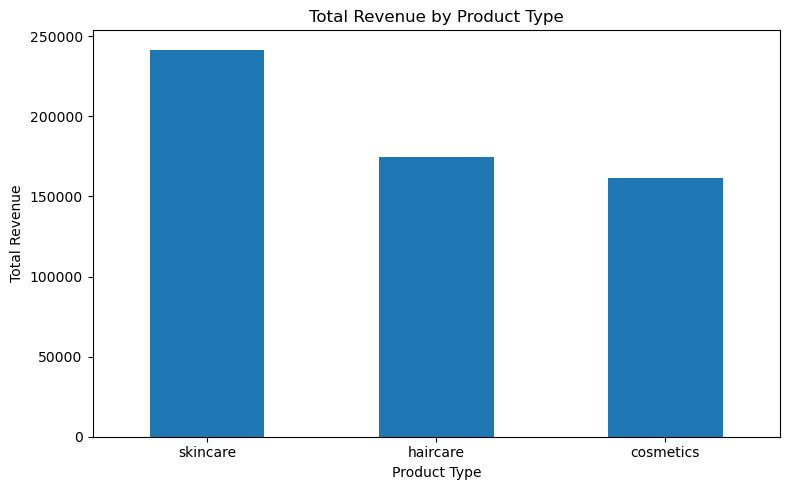

In [7]:
plt.figure(figsize=(8, 5))

revenue_by_product.plot(kind="bar")

plt.xlabel("Product Type")
plt.ylabel("Total Revenue")
plt.title("Total Revenue by Product Type")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [8]:
best_revenue_product = revenue_by_product.idxmax()

print(
    f"Business Insight: {best_revenue_product} generates the highest total revenue "
    "among the product types."
)

Business Insight: skincare generates the highest total revenue among the product types.


In [9]:
sales_by_product = (
    df.groupby("Product type")["Number of products sold"]
    .sum()
    .sort_values(ascending=False)
)

sales_by_product

Product type
skincare     20731
haircare     13611
cosmetics    11757
Name: Number of products sold, dtype: int64

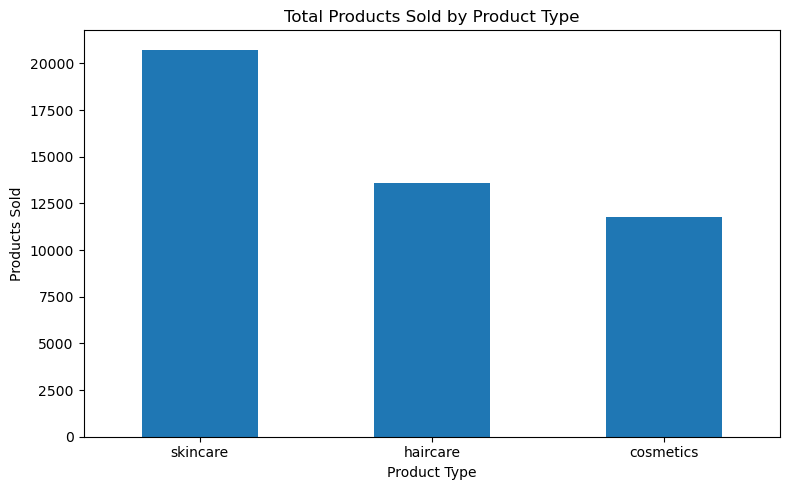

In [10]:
plt.figure(figsize=(8, 5))

sales_by_product.plot(kind="bar")

plt.xlabel("Product Type")
plt.ylabel("Products Sold")
plt.title("Total Products Sold by Product Type")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [11]:
best_sales_product = sales_by_product.idxmax()

print(
    f"Business Insight: {best_sales_product} has the highest sales volume."
)

Business Insight: skincare has the highest sales volume.


In [12]:
profit_by_product = (
    df.groupby("Product type")["Estimated Profit"]
    .sum()
    .sort_values(ascending=False)
)

profit_by_product

Product type
skincare     239472.048328
haircare     172606.955095
cosmetics    160244.331084
Name: Estimated Profit, dtype: float64

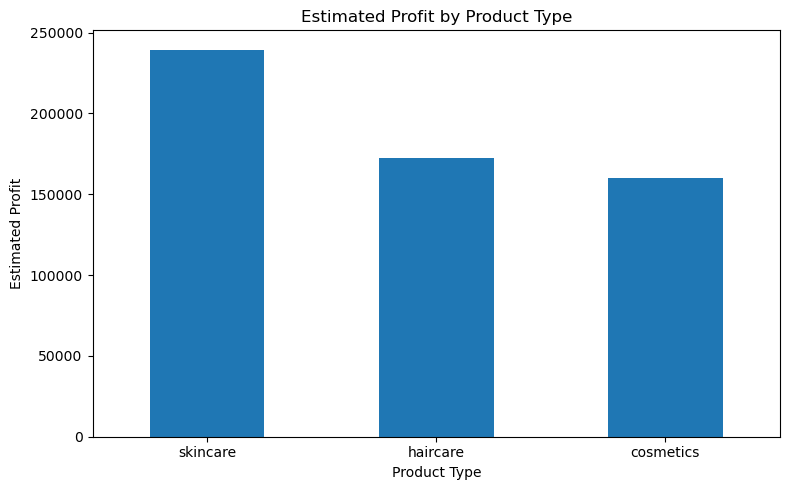

In [13]:
plt.figure(figsize=(8, 5))

profit_by_product.plot(kind="bar")

plt.xlabel("Product Type")
plt.ylabel("Estimated Profit")
plt.title("Estimated Profit by Product Type")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [14]:
most_profitable_product = profit_by_product.idxmax()

print(
    f"Business Insight: {most_profitable_product} has the highest estimated profit."
)

Business Insight: skincare has the highest estimated profit.


In [15]:
transport_cost = (
    df.groupby("Transportation modes")["Shipping costs"]
    .mean()
    .sort_values()
)

transport_cost

Transportation modes
Sea     4.970294
Rail    5.469098
Road    5.542115
Air     6.017839
Name: Shipping costs, dtype: float64

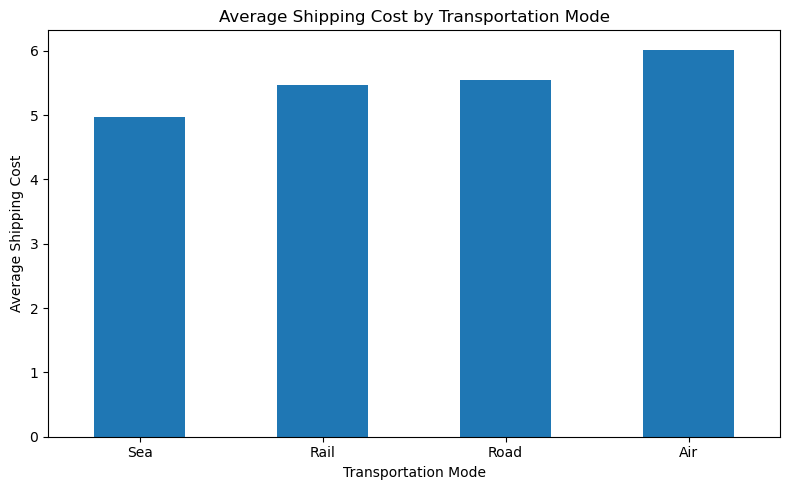

In [16]:
plt.figure(figsize=(8, 5))

transport_cost.plot(kind="bar")

plt.xlabel("Transportation Mode")
plt.ylabel("Average Shipping Cost")
plt.title("Average Shipping Cost by Transportation Mode")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [17]:
cheapest_transport = transport_cost.idxmin()

print(
    f"Business Insight: {cheapest_transport} has the lowest average shipping cost."
)

Business Insight: Sea has the lowest average shipping cost.


In [18]:
supplier_production = (
    df.groupby("Supplier name")["Production volumes"]
    .sum()
    .sort_values(ascending=False)
)

supplier_production

Supplier name
Supplier 2    14105
Supplier 1    13545
Supplier 4    11756
Supplier 5     9381
Supplier 3     7997
Name: Production volumes, dtype: int64

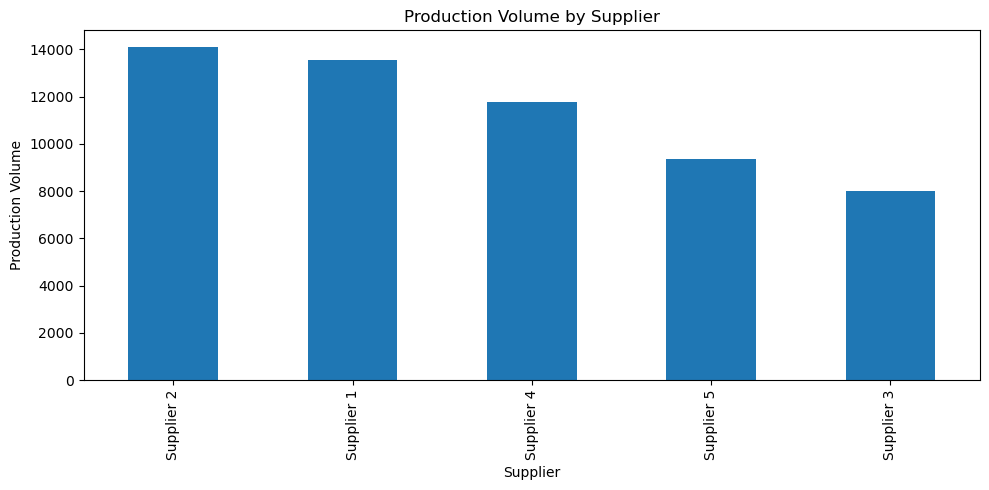

In [19]:
plt.figure(figsize=(10, 5))

supplier_production.plot(kind="bar")

plt.xlabel("Supplier")
plt.ylabel("Production Volume")
plt.title("Production Volume by Supplier")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [20]:
top_supplier = supplier_production.idxmax()

print(
    f"Business Insight: {top_supplier} has the highest production volume."
)

Business Insight: Supplier 2 has the highest production volume.


In [21]:
supplier_defects = (
    df.groupby("Supplier name")["Defect rates"]
    .mean()
    .sort_values(ascending=False)
)

supplier_defects

Supplier name
Supplier 5    2.665408
Supplier 3    2.465786
Supplier 2    2.362750
Supplier 4    2.337397
Supplier 1    1.803630
Name: Defect rates, dtype: float64

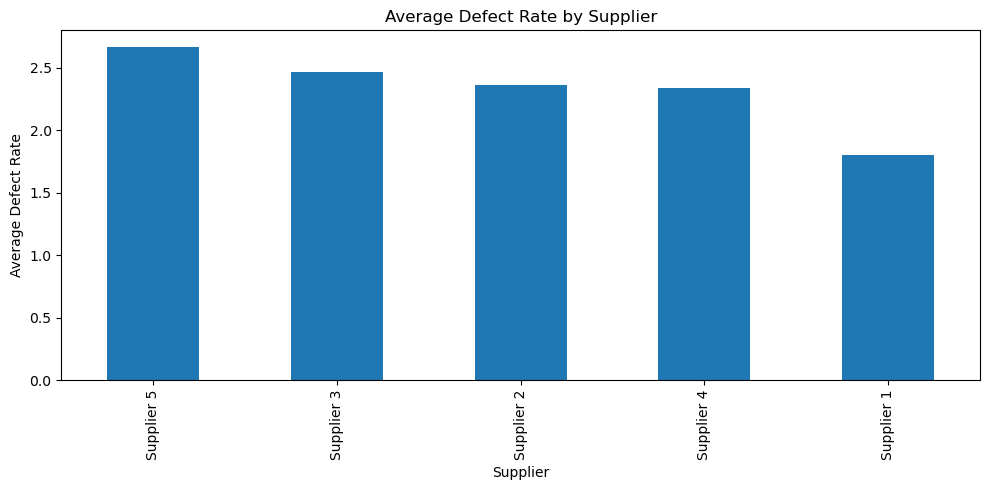

In [22]:
plt.figure(figsize=(10, 5))

supplier_defects.plot(kind="bar")

plt.xlabel("Supplier")
plt.ylabel("Average Defect Rate")
plt.title("Average Defect Rate by Supplier")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [23]:
highest_defect_supplier = supplier_defects.idxmax()

print(
    f"Business Insight: {highest_defect_supplier} has the highest average defect rate."
)

Business Insight: Supplier 5 has the highest average defect rate.


In [24]:
inventory_turnover = (
    df.groupby("Product type")["Inventory Turnover"]
    .mean()
    .sort_values(ascending=False)
)

inventory_turnover

Product type
skincare     45.416858
haircare     18.527163
cosmetics    16.593001
Name: Inventory Turnover, dtype: float64

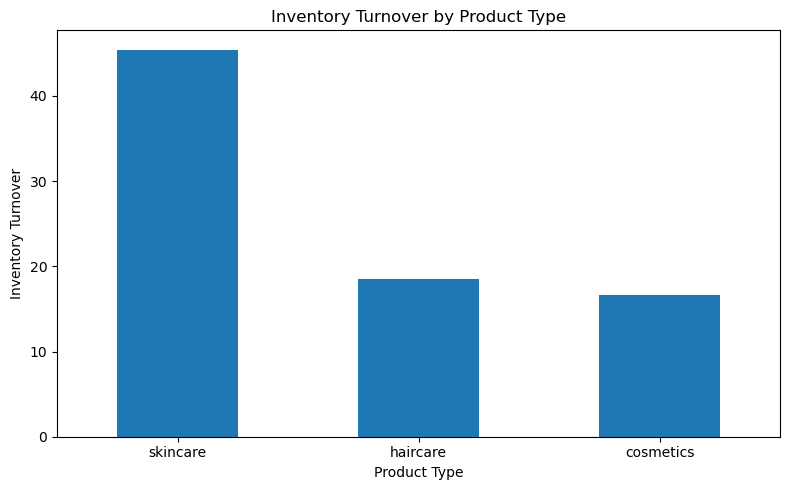

In [25]:
plt.figure(figsize=(8, 5))

inventory_turnover.plot(kind="bar")

plt.xlabel("Product Type")
plt.ylabel("Inventory Turnover")
plt.title("Inventory Turnover by Product Type")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [26]:
best_inventory_product = inventory_turnover.idxmax()

print(
    f"Business Insight: {best_inventory_product} has the highest average inventory turnover."
)

Business Insight: skincare has the highest average inventory turnover.


In [27]:
product_defects = (
    df.groupby("Product type")["Defect rates"]
    .mean()
    .sort_values(ascending=False)
)

product_defects

Product type
haircare     2.483150
skincare     2.334681
cosmetics    1.919287
Name: Defect rates, dtype: float64

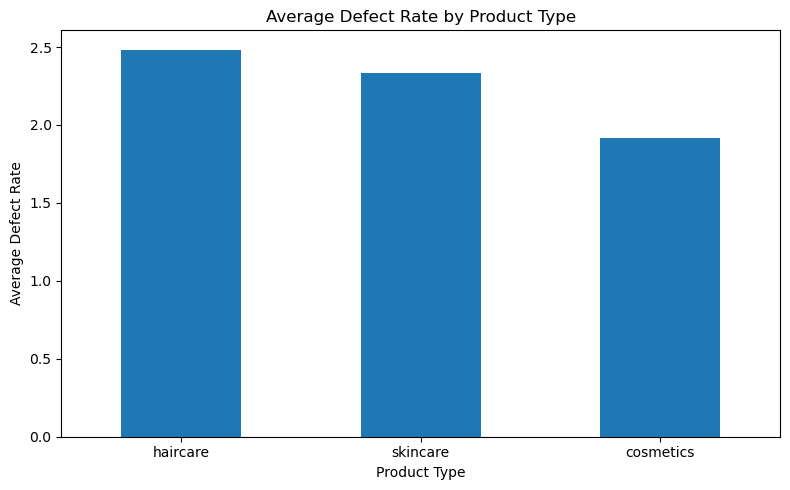

In [28]:
plt.figure(figsize=(8, 5))

product_defects.plot(kind="bar")

plt.xlabel("Product Type")
plt.ylabel("Average Defect Rate")
plt.title("Average Defect Rate by Product Type")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [29]:
highest_defect_product = product_defects.idxmax()

print(
    f"Business Insight: {highest_defect_product} has the highest average defect rate."
)

Business Insight: haircare has the highest average defect rate.


In [31]:
shipping_by_product = (
    df.groupby("Product type")["Shipping costs"]
    .mean()
    .sort_values(ascending=False)
)

shipping_by_product

Product type
cosmetics    6.060141
haircare     5.907757
skincare     4.909688
Name: Shipping costs, dtype: float64

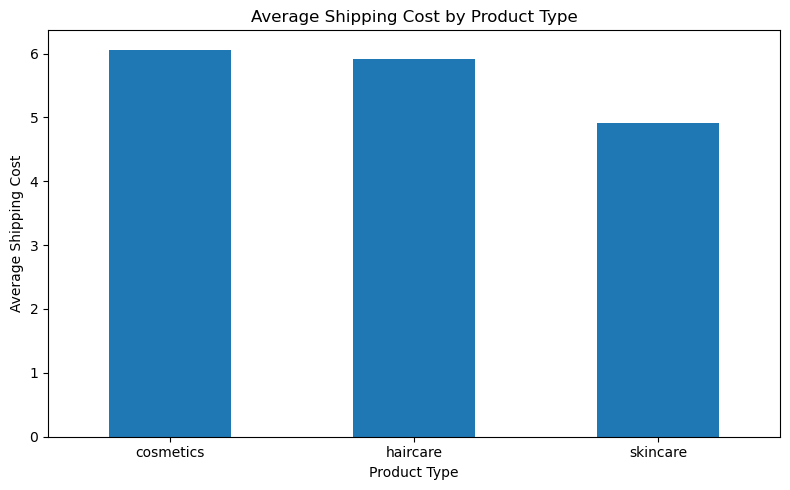

In [32]:
plt.figure(figsize=(8, 5))

shipping_by_product.plot(kind="bar")

plt.xlabel("Product Type")
plt.ylabel("Average Shipping Cost")
plt.title("Average Shipping Cost by Product Type")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [33]:
highest_shipping_product = shipping_by_product.idxmax()

print(
    f"Business Insight: {highest_shipping_product} has the highest average shipping cost."
)

Business Insight: cosmetics has the highest average shipping cost.


In [34]:
profit_margin_by_product = (
    df.groupby("Product type")["Profit Margin"]
    .mean()
    .sort_values(ascending=False)
)

profit_margin_by_product

Product type
cosmetics    99.020531
skincare     98.544647
haircare     98.410154
Name: Profit Margin, dtype: float64

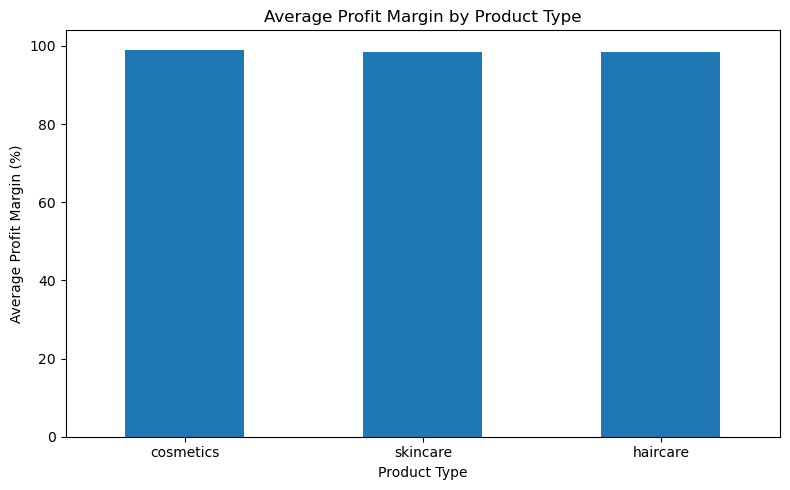

In [35]:
plt.figure(figsize=(8, 5))

profit_margin_by_product.plot(kind="bar")

plt.xlabel("Product Type")
plt.ylabel("Average Profit Margin (%)")
plt.title("Average Profit Margin by Product Type")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [36]:
best_margin_product = profit_margin_by_product.idxmax()

print(
    f"Business Insight: {best_margin_product} has the highest average profit margin."
)

Business Insight: cosmetics has the highest average profit margin.


In [37]:
print("KEY SUPPLY CHAIN AREAS TO MONITOR")
print("-" * 50)

print("1. Products with high defect rates.")
print("2. Suppliers with high defect rates.")
print("3. Transportation modes with high shipping costs.")
print("4. Products with low inventory turnover.")
print("5. Products with low profit margins.")
print("6. Products with high shipping costs.")

KEY SUPPLY CHAIN AREAS TO MONITOR
--------------------------------------------------
1. Products with high defect rates.
2. Suppliers with high defect rates.
3. Transportation modes with high shipping costs.
4. Products with low inventory turnover.
5. Products with low profit margins.
6. Products with high shipping costs.


In [38]:
print("BUSINESS RECOMMENDATIONS")
print("-" * 50)

print("1. Focus on high-revenue and high-profit product categories.")
print("2. Monitor suppliers with high defect rates and improve quality control.")
print("3. Evaluate transportation modes with high shipping costs.")
print("4. Improve inventory planning for products with low inventory turnover.")
print("5. Monitor products with low profit margins.")
print("6. Reduce unnecessary shipping and manufacturing costs.")
print("7. Use data-driven insights for better supply-chain decision making.")

BUSINESS RECOMMENDATIONS
--------------------------------------------------
1. Focus on high-revenue and high-profit product categories.
2. Monitor suppliers with high defect rates and improve quality control.
3. Evaluate transportation modes with high shipping costs.
4. Improve inventory planning for products with low inventory turnover.
5. Monitor products with low profit margins.
6. Reduce unnecessary shipping and manufacturing costs.
7. Use data-driven insights for better supply-chain decision making.


In [39]:
business_summary = pd.DataFrame({
    "Metric": [
        "Highest Revenue Product",
        "Highest Sales Product",
        "Highest Profit Product",
        "Lowest Shipping Cost Mode",
        "Highest Production Supplier",
        "Highest Defect Supplier",
        "Highest Inventory Turnover Product",
        "Highest Defect Product",
        "Highest Shipping Cost Product",
        "Highest Profit Margin Product"
    ],
    
    "Result": [
        best_revenue_product,
        best_sales_product,
        most_profitable_product,
        cheapest_transport,
        top_supplier,
        highest_defect_supplier,
        best_inventory_product,
        highest_defect_product,
        highest_shipping_product,
        best_margin_product
    ]
})

business_summary

,Metric,Result
0,Highest Revenue Product,skincare
1,Highest Sales Product,skincare
2,Highest Profit Product,skincare
3,Lowest Shipping Cost Mode,Sea
4,Highest Production Supplier,Supplier 2
5,Highest Defect Supplier,Supplier 5
6,Highest Inventory Turnover Product,skincare
7,Highest Defect Product,haircare
8,Highest Shipping Cost Product,cosmetics
9,Highest Profit Margin Product,cosmetics


In [40]:
business_summary.to_csv(
    "business_insights_summary.csv",
    index=False
)

In [41]:
print("FINAL CONCLUSION")
print("-" * 50)

print(
    "The analysis provides insights into product performance, supplier performance, "
    "transportation costs, inventory efficiency, profitability, and quality."
)

print(
    "These insights can help the business improve inventory management, "
    "reduce supply-chain costs, improve product quality, and increase profitability."
)

FINAL CONCLUSION
--------------------------------------------------
The analysis provides insights into product performance, supplier performance, transportation costs, inventory efficiency, profitability, and quality.
These insights can help the business improve inventory management, reduce supply-chain costs, improve product quality, and increase profitability.


In [42]:
print("Business insights analysis completed successfully! ✅")

Business insights analysis completed successfully! ✅
